# 02 — Train pneumonia classifier

Fine-tune ResNet50 on chest X-rays. The CLI for full runs:
`python scripts/train.py --config configs/default.yaml`

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cxr_pneumonia.config import load_config
from cxr_pneumonia.train import get_device, train

cfg = load_config(ROOT / "configs" / "default.yaml")
# YAML paths are relative to the project root, not the notebooks/ folder
cfg.data_dir = str((ROOT / cfg.data_dir).resolve())
cfg.artifacts_dir = str((ROOT / cfg.artifacts_dir).resolve())
# Shorter run for notebook experimentation — raise epochs for a real model
cfg.epochs = 3
cfg.batch_size = 16
cfg.num_workers = 0
print("device:", get_device())
print("data_dir:", cfg.data_path)
print(cfg)

device: mps
data_dir: /Users/htethtetoo/medical-image-analysis/data/chest_xray
Config(seed=42, data_dir='/Users/htethtetoo/medical-image-analysis/data/chest_xray', artifacts_dir='/Users/htethtetoo/medical-image-analysis/artifacts', image_size=224, batch_size=16, num_workers=0, epochs=3, learning_rate=0.0001, weight_decay=0.0001, patience=3, freeze_backbone=False, num_classes=2, class_names=['NORMAL', 'PNEUMONIA'])


In [5]:
best_path = train(cfg)
best_path

Epoch 1/3  train_loss=0.1330  val_loss=0.0457  val_acc=0.9828  val_f1=0.9884  val_auc=0.9988
  saved best checkpoint → /Users/htethtetoo/medical-image-analysis/artifacts/best.pt


Epoch 2/3  train_loss=0.0661  val_loss=0.1887  val_acc=0.9349  val_f1=0.9542  val_auc=0.9982


Epoch 3/3  train_loss=0.0459  val_loss=0.0522  val_acc=0.9808  val_f1=0.9870  val_auc=0.9988


PosixPath('/Users/htethtetoo/medical-image-analysis/artifacts/best.pt')

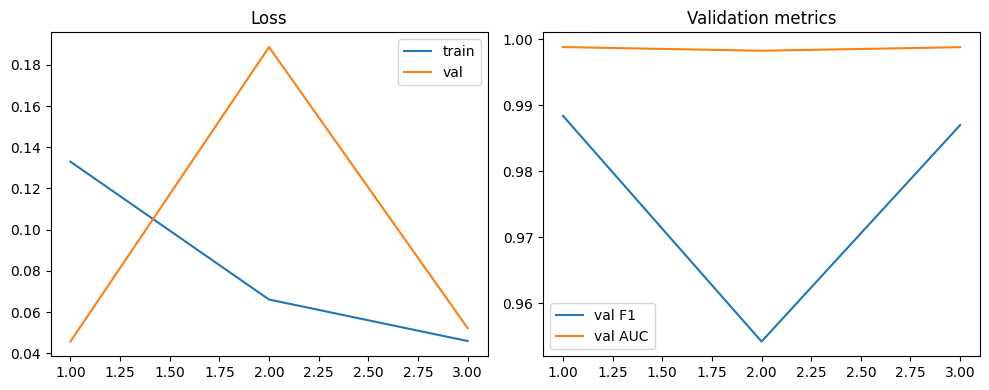

,epoch,train_loss,val_loss,val_accuracy,val_f1,val_auc
0,1,0.133012,0.045683,0.982759,0.988387,0.998808
1,2,0.066082,0.188679,0.934866,0.954178,0.998250
2,3,0.045937,0.052213,0.980843,0.986979,0.998788


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(cfg.artifacts_path / "train_history.csv")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["epoch"], history["val_f1"], label="val F1")
axes[1].plot(history["epoch"], history["val_auc"], label="val AUC")
axes[1].set_title("Validation metrics")
axes[1].legend()
plt.tight_layout()
plt.show()
history